In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

df = pd.read_excel("/content/sample_data/ApexPlanet_DataAnalytics_Dataset.xlsx")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 1000
Columns: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB


In [8]:
data_dictionary = pd.DataFrame({
    "Column":[
        "Order_ID","Order_Date","Customer_ID",
        "Customer_Name","Age","Gender",
        "City","Product","Category",
        "Quantity","Unit_Price","Total_Sales"
    ],

    "Description":[
        "Unique order identifier",
        "Date of order",
        "Unique customer identifier",
        "Customer name",
        "Customer age",
        "Customer gender",
        "Customer city",
        "Purchased product",
        "Product category",
        "Quantity purchased",
        "Price per unit",
        "Revenue generated"
    ]
})

data_dictionary

,Column,Description
0,Order_ID,Unique order identifier
1,Order_Date,Date of order
2,Customer_ID,Unique customer identifier
3,Customer_Name,Customer name
4,Age,Customer age
5,Gender,Customer gender
6,City,Customer city
7,Product,Purchased product
8,Category,Product category
9,Quantity,Quantity purchased


In [9]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,20
Gender,0
City,13
Product,0
Category,0
Quantity,0


In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
df["Order_ID"].duplicated().sum()

np.int64(8)

In [14]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["City"] = df["City"].fillna(df["City"].mode()[0])
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,0
Gender,0
City,0
Product,0
Category,0
Quantity,0


In [17]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       1000 non-null   object        
 1   Order_Date     1000 non-null   datetime64[ns]
 2   Customer_ID    1000 non-null   object        
 3   Customer_Name  1000 non-null   object        
 4   Age            1000 non-null   float64       
 5   Gender         1000 non-null   object        
 6   City           1000 non-null   object        
 7   Product        1000 non-null   object        
 8   Category       1000 non-null   object        
 9   Quantity       1000 non-null   int64         
 10  Unit_Price     1000 non-null   float64       
 11  Total_Sales    1000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(7)
memory usage: 93.9+ KB


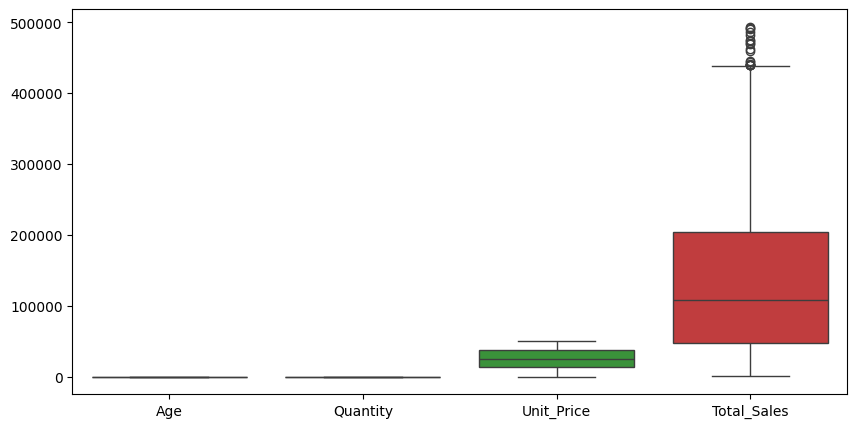

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[["Age","Quantity","Unit_Price","Total_Sales"]])
plt.show()

In [19]:
df["Sales_Per_Unit"] = df["Total_Sales"] / df["Quantity"]

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Sales_Per_Unit
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2829.77
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,27906.16
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,37491.06
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,28541.36
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,14036.59


In [22]:
from google.colab import files
df.to_csv("cleaned_sales_data.csv", index=False)
files.download("cleaned_sales_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>